In [ ]:
# JupyterLite needs openpyxl to read Excel files
%pip install -q openpyxl

# Marketing data

In [68]:
import pandas as pd

In [69]:
marketing = pd.read_excel('Marketing.xlsx', skiprows = 1)
marketing.head()

,week commencing,Total Sales,Unnamed: 2,TV,Radio,Online,Outdoor
0,2015-01-05,257891.755133,NaN,108.957426,344.090633,56.823995,213.192687
1,2015-01-12,278290.790130,NaN,2122.699334,270.616484,81.185663,399.593715
2,2015-01-19,166692.186734,NaN,530.989012,438.453928,133.905298,128.232653
3,2015-01-26,190043.304484,NaN,2144.477161,828.541337,60.899658,573.100037
4,2015-02-02,119568.853604,NaN,3423.889734,983.883215,78.963178,470.492436


In [70]:
marketing = marketing.drop(columns='Unnamed: 2')
marketing.head()

,week commencing,Total Sales,TV,Radio,Online,Outdoor
0,2015-01-05,257891.755133,108.957426,344.090633,56.823995,213.192687
1,2015-01-12,278290.790130,2122.699334,270.616484,81.185663,399.593715
2,2015-01-19,166692.186734,530.989012,438.453928,133.905298,128.232653
3,2015-01-26,190043.304484,2144.477161,828.541337,60.899658,573.100037
4,2015-02-02,119568.853604,3423.889734,983.883215,78.963178,470.492436


In [71]:
marketing['target_met'] = marketing['Total Sales'] >= 200000
marketing.head()

,week commencing,Total Sales,TV,Radio,Online,Outdoor,target_met
0,2015-01-05,257891.755133,108.957426,344.090633,56.823995,213.192687,True
1,2015-01-12,278290.790130,2122.699334,270.616484,81.185663,399.593715,True
2,2015-01-19,166692.186734,530.989012,438.453928,133.905298,128.232653,False
3,2015-01-26,190043.304484,2144.477161,828.541337,60.899658,573.100037,False
4,2015-02-02,119568.853604,3423.889734,983.883215,78.963178,470.492436,False


# Discovery

In [72]:
marketing.groupby('target_met').mean()

,week commencing,Total Sales,TV,Radio,Online,Outdoor
target_met,,,,,,
False,2017-10-30 05:22:11.506849280,152471.419116,2323.500419,465.919968,50.458424,234.458541
True,2018-08-11 21:38:49.411764736,253905.155735,3188.701718,638.045929,61.072797,333.812339


# Preparation and model planning

In [73]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    marketing,
    random_state = 15
)

In [74]:
dependent = train['target_met']

In [75]:
independent = train[['TV','Radio','Online','Outdoor']]

In [76]:
import statsmodels.api as sm

independent = sm.add_constant(independent)
independent.head()

,const,TV,Radio,Online,Outdoor
71,1.0,457.554166,424.250541,13.244741,328.432673
98,1.0,3394.616035,698.291669,23.523728,478.898450
273,1.0,2211.291425,521.564783,27.495591,222.094974
24,1.0,1595.895795,941.424061,56.201249,19.356975
106,1.0,2659.104584,848.184482,55.388013,661.803215


# Model Building

In [77]:
# Build the model
model_1 = sm.Logit(
    dependent,
    independent
).fit()

# Print model summary statistics
model_1.summary()

Optimization terminated successfully.
         Current function value: 0.534673
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             target_met   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                  0.1391
Time:                        19:28:19   Log-Likelihood:                -128.32
converged:                       True   LL-Null:                       -149.06
Covariance Type:            nonrobust   LLR p-value:                 2.140e-08
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3698      0.499     -6.750      0.000      -4.348      -2.391
TV             0.0003   9.27e-05      2.816      0.005    7.94e-05       0.000
Radio          0.0012      0.000      2.577      0.010       0.000       0.002
Online         0.0056      0.004      1.318      0.188      -0.003       0.014
Outdoor        0.0031      0.001      3.294      0.001       0.001       0.005
==============================================================================
"""

# Analysing the results

In [78]:
test_independent = test[['TV', 'Radio', 'Online', 'Outdoor']]

test_independent = sm.add_constant(test_independent)

test_predictions = model_1.predict(test_independent)

In [79]:
test_predictions = test_predictions >= 0.5
test_actual = test['target_met']

              precision    recall  f1-score   support

       False       0.73      0.96      0.83        54
        True       0.80      0.30      0.43        27

    accuracy                           0.74        81
   macro avg       0.77      0.63      0.63        81
weighted avg       0.75      0.74      0.70        81



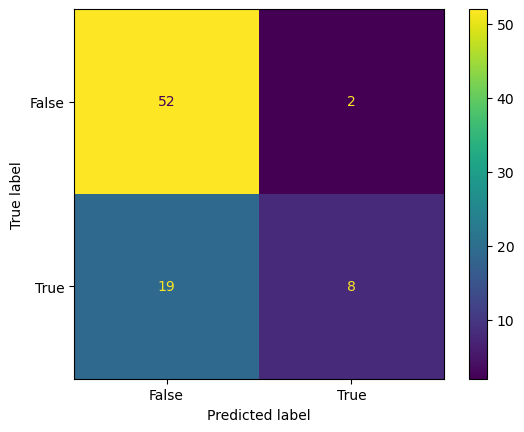

In [80]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Assuming test_predictions and test_actual are pre-defined lists or arrays
# Calculate the confusion matrix
cm = confusion_matrix(test_actual, test_predictions, labels=list(set(test_actual))) #Use set to get unique labels.

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(set(test_actual))) #Use set to get unique labels.

# Generate and print the classification report
print(classification_report(test_actual, test_predictions))


# Plot the confusion matrix
disp.plot()
# Show the plot
plt.show()